In [1]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix
)

from sklearn.preprocessing import LabelEncoder

from xgboost import XGBClassifier

import joblib

In [2]:
df = pd.read_csv(
    "../data/raw/accepted_2007_to_2018Q4.csv.gz",
    nrows=500000,
    low_memory=False
)

print(df.shape) 

(500000, 151)


In [3]:
df = df[
    df["loan_status"].isin([
        "Fully Paid",
        "Charged Off"
    ])
]

df["target"] = df["loan_status"].map({
    "Fully Paid": 0,
    "Charged Off": 1
})

df["fico_score"] = (
    df["fico_range_low"] +
    df["fico_range_high"]
) / 2

df["earliest_cr_line"] = pd.to_datetime(
    df["earliest_cr_line"],
    format="%b-%Y",
    errors="coerce"
)

df["credit_history_years"] = (
    pd.Timestamp("2019-01-01") -
    df["earliest_cr_line"]
).dt.days / 365

df["loan_income_ratio"] = (
    df["loan_amnt"] /
    (df["annual_inc"] + 1)
)

df["balance_income_ratio"] = (
    df["tot_cur_bal"] /
    (df["annual_inc"] + 1)
)

df["accounts_per_year"] = (
    df["total_acc"] /
    (df["credit_history_years"] + 1)
)

df["credit_utilization_score"] = (
    df["revol_util"] *
    df["bc_util"]
)
print(df["target"].value_counts())

target
0    312340
1     78824
Name: count, dtype: int64


C:\Windows\Temp\ipykernel_3868\548219865.py:8: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df["target"] = df["loan_status"].map({
C:\Windows\Temp\ipykernel_3868\548219865.py:13: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df["fico_score"] = (
C:\Windows\Temp\ipykernel_3868\548219865.py:24: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented

In [4]:
FEATURES = [

    "loan_amnt",
    "annual_inc",
    "dti",
    "installment",

    "fico_score",
    "tot_cur_bal",
    "revol_util",

    "emp_length",
    "home_ownership",

    "inq_last_6mths",
    "delinq_2yrs",

    "pct_tl_nvr_dlq",

    "open_acc",
    "total_acc",

    "bc_util",
    "avg_cur_bal",
    "acc_open_past_24mths",

    "grade",
    "sub_grade",
    "purpose",
    "verification_status",

    "credit_history_years",
    "loan_income_ratio",
    "balance_income_ratio",
    "accounts_per_year",
    "credit_utilization_score"
]

In [5]:
df_model = df[FEATURES + ["target"]].copy()

df_model = df_model.replace(
    [np.inf, -np.inf],
    np.nan
)

for col in df_model.columns:
    if col != "target":
        df_model[col] = df_model[col].fillna(
            df_model[col].median()
            if pd.api.types.is_numeric_dtype(df_model[col])
            else df_model[col].mode()[0]
        )

# Fill numeric columns
numeric_cols = [
    "loan_amnt",
    "annual_inc",
    "dti",
    "installment",
    "fico_score",
    "tot_cur_bal",
    "revol_util",
    "inq_last_6mths",
    "delinq_2yrs",
    "pct_tl_nvr_dlq",
    "open_acc",
    "total_acc",
    "bc_util",
    "avg_cur_bal",
    "acc_open_past_24mths",
    "credit_history_years"
]

for col in numeric_cols:
    df_model[col] = df_model[col].fillna(
        df_model[col].median()
    )

df_model["emp_length"] = (
    df_model["emp_length"]
    .astype(str)
    .str.replace("years", "", regex=False)
    .str.replace("year", "", regex=False)
    .str.replace("+", "", regex=False)
    .str.replace("< 1", "0", regex=False)
    .str.strip()
)

df_model["emp_length"] = pd.to_numeric(
    df_model["emp_length"],
    errors="coerce"
)

df_model["emp_length"] = (
    df_model["emp_length"]
    .fillna(df_model["emp_length"].median())
)

In [6]:
df_model["revol_util"] = (
    df_model["revol_util"]
    .fillna(df_model["revol_util"].median())
)

df_model["dti"] = (
    df_model["dti"]
    .fillna(df_model["dti"].median())
)


In [7]:
df_model.isnull().sum()
#remove

loan_amnt                   0
annual_inc                  0
dti                         0
installment                 0
fico_score                  0
tot_cur_bal                 0
revol_util                  0
emp_length                  0
home_ownership              0
inq_last_6mths              0
delinq_2yrs                 0
pct_tl_nvr_dlq              0
open_acc                    0
total_acc                   0
bc_util                     0
avg_cur_bal                 0
acc_open_past_24mths        0
grade                       0
sub_grade                   0
purpose                     0
verification_status         0
credit_history_years        0
loan_income_ratio           0
balance_income_ratio        0
accounts_per_year           0
credit_utilization_score    0
target                      0
dtype: int64

In [8]:


for col in [
    "bc_util",
    "avg_cur_bal",
    "acc_open_past_24mths"
]:

    df_model[col] = (
        df_model[col]
        .fillna(df_model[col].median())
    )
print(df_model["home_ownership"].unique())


<StringArray>
['MORTGAGE', 'RENT', 'OWN', 'ANY']
Length: 4, dtype: str


In [9]:
from sklearn.preprocessing import LabelEncoder

categorical_cols = [
    "home_ownership",
    "grade",
    "sub_grade",
    "purpose",
    "verification_status"
]

encoders = {}

for col in categorical_cols:

    le = LabelEncoder()

    df_model[col] = le.fit_transform(
        df_model[col].astype(str)
    )

    encoders[col] = le

for col in categorical_cols:
    print(col)
    print(encoders[col].classes_)
    print()

home_ownership
['ANY' 'MORTGAGE' 'OWN' 'RENT']

grade
['A' 'B' 'C' 'D' 'E' 'F' 'G']

sub_grade
['A1' 'A2' 'A3' 'A4' 'A5' 'B1' 'B2' 'B3' 'B4' 'B5' 'C1' 'C2' 'C3' 'C4'
 'C5' 'D1' 'D2' 'D3' 'D4' 'D5' 'E1' 'E2' 'E3' 'E4' 'E5' 'F1' 'F2' 'F3'
 'F4' 'F5' 'G1' 'G2' 'G3' 'G4' 'G5']

purpose
['car' 'credit_card' 'debt_consolidation' 'educational' 'home_improvement'
 'house' 'major_purchase' 'medical' 'moving' 'other' 'renewable_energy'
 'small_business' 'vacation' 'wedding']

verification_status
['Not Verified' 'Source Verified' 'Verified']



In [10]:
print(df_model.dtypes)
print(df_model.isnull().sum().sum())

loan_amnt                   float64
annual_inc                  float64
dti                         float64
installment                 float64
fico_score                  float64
tot_cur_bal                 float64
revol_util                  float64
emp_length                    int64
home_ownership                int64
inq_last_6mths              float64
delinq_2yrs                 float64
pct_tl_nvr_dlq              float64
open_acc                    float64
total_acc                   float64
bc_util                     float64
avg_cur_bal                 float64
acc_open_past_24mths        float64
grade                         int64
sub_grade                     int64
purpose                       int64
verification_status           int64
credit_history_years        float64
loan_income_ratio           float64
balance_income_ratio        float64
accounts_per_year           float64
credit_utilization_score    float64
target                        int64
dtype: object
0


In [11]:
# np.random.seed(42)

# df_model["psychometric_score"] = np.random.randint(
#     50,
#     100,
#     len(df_model)
# )

# df_model["phone_bill_score"] = np.random.randint(
#     50,
#     100,
#     len(df_model)
# )

# df_model["ecommerce_score"] = np.random.randint(
#     40,
#     100,
#     len(df_model)
# )

In [12]:
X = df_model.drop("target", axis=1)

y = df_model["target"]

In [13]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

negative = (y_train == 0).sum()
positive = (y_train == 1).sum()

scale_weight = negative / positive

print("Negative:", negative)
print("Positive:", positive)
print("Scale Weight:", scale_weight)

Negative: 249872
Positive: 63059
Scale Weight: 3.9625112989422604


In [14]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(
    random_state=42
)

X_train_smote, y_train_smote = smote.fit_resample(
    X_train,
    y_train
)

print(y_train.value_counts())
print(y_train_smote.value_counts())

target
0    249872
1     63059
Name: count, dtype: int64
target
0    249872
1    249872
Name: count, dtype: int64


In [15]:
from sklearn.model_selection import RandomizedSearchCV

params = {
    "max_depth": [4, 6, 8, 10],
    "learning_rate": [0.01, 0.03, 0.05],
    "n_estimators": [300, 500, 800],
    "subsample": [0.8, 1.0],
    "colsample_bytree": [0.8, 1.0]
}

search = RandomizedSearchCV(
    estimator=XGBClassifier(
        random_state=42,
        eval_metric="logloss"
    ),
    param_distributions=params,
    n_iter=15,
    scoring="roc_auc",
    cv=3,
    verbose=2,
    n_jobs=-1
)

search.fit(
    X_train_smote,
    y_train_smote
)

print(search.best_params_)
print(search.best_score_)

Fitting 3 folds for each of 15 candidates, totalling 45 fits
{'subsample': 0.8, 'n_estimators': 800, 'max_depth': 10, 'learning_rate': 0.01, 'colsample_bytree': 0.8}
0.9083838575573685


In [16]:
best_model = search.best_estimator_

In [17]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix
)

# Probabilities
probs = best_model.predict_proba(X_test)[:, 1]

# Best threshold found earlier
threshold = 0.26

# Convert probabilities to predictions
pred = (probs > threshold).astype(int)

print("="*50)
print(f"Threshold : {threshold}")
print("="*50)

print("Accuracy :", accuracy_score(y_test, pred))
print("Precision:", precision_score(y_test, pred))
print("Recall   :", recall_score(y_test, pred))
print("F1 Score :", f1_score(y_test, pred))
print("ROC AUC  :", roc_auc_score(y_test, probs))

print("\nConfusion Matrix")
print(confusion_matrix(y_test, pred))

Threshold : 0.26
Accuracy : 0.7125509695397083
Precision: 0.36644284635861574
Recall   : 0.5850301300348875
F1 Score : 0.4506278399374603
ROC AUC  : 0.7321469005705294

Confusion Matrix
[[46522 15946]
 [ 6542  9223]]


In [18]:
# model = XGBClassifier(
#     n_estimators=1000,
#     max_depth=8,
#     learning_rate=0.03,
#     min_child_weight=3,
#     subsample=0.8,
#     colsample_bytree=0.8,
#     scale_pos_weight=1,
#     random_state=42,
#     eval_metric="logloss"
# )

# model.fit(
#     X_train_smote,
#     y_train_smote
# )

In [19]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

probs = best_model.predict_proba(X_test)[:,1]

best_threshold = 0
best_f1 = 0

for threshold in np.arange(0.1, 0.9, 0.01):

    pred = (probs > threshold).astype(int)

    f1 = f1_score(y_test, pred)

    if f1 > best_f1:
        best_f1 = f1
        best_threshold = threshold

print("Best Threshold:", best_threshold)
print("Best F1:", best_f1)


Best Threshold: 0.24999999999999992
Best F1: 0.45245377123229663


In [20]:
from sklearn.metrics import roc_auc_score

probs = best_model.predict_proba(X_test)[:,1]

print(
    "ROC AUC:",
    roc_auc_score(y_test, probs)
)

ROC AUC: 0.7321469005705294


In [21]:
importance_df = pd.DataFrame({
    "feature": X.columns,
    "importance": best_model.feature_importances_
})

importance_df.sort_values(
    "importance",
    ascending=False
)

,feature,importance
9,inq_last_6mths,0.454929
18,sub_grade,0.115483
17,grade,0.093614
16,acc_open_past_24mths,0.080403
10,delinq_2yrs,0.066795
4,fico_score,0.041006
11,pct_tl_nvr_dlq,0.025756
7,emp_length,0.018887
20,verification_status,0.015265
19,purpose,0.009979


In [22]:
import joblib

import joblib

joblib.dump(best_model, "../models/model_v1.pkl")
joblib.dump(encoders, "../models/encoders.pkl")

['../models/encoders.pkl']

In [23]:
y.value_counts(normalize=True)

target
0    0.798489
1    0.201511
Name: proportion, dtype: float64

In [24]:
def risk_to_credit_score(prob):

    score = int(
        300 + (1 - prob) * 550
    )

    return score
print(risk_to_credit_score(0.10))
print(risk_to_credit_score(0.50))
print(risk_to_credit_score(0.80))

def risk_level(prob):

    if prob < 0.20:
        return "LOW"

    elif prob < 0.50:
        return "MEDIUM"

    else:
        return "HIGH"
print(risk_level(0.1))
print(risk_level(0.3))
print(risk_level(0.8))

sample = X_test.iloc[[0]]

prob = best_model.predict_proba(sample)[0][1]

score = risk_to_credit_score(prob)

risk = risk_level(prob)

print("Default Probability:", prob)
print("Credit Score:", score)
print("Risk Level:", risk)

795
575
410
LOW
MEDIUM
HIGH
Default Probability: 0.2175462
Credit Score: 730
Risk Level: MEDIUM


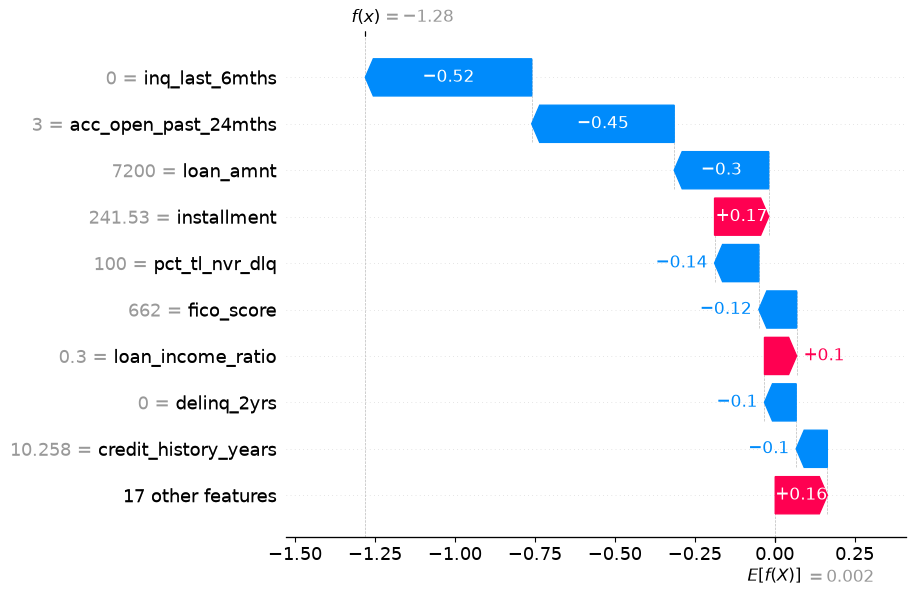

In [25]:
import shap

explainer = shap.TreeExplainer(best_model)

sample = X_test.iloc[[0]]

shap_values = explainer.shap_values(sample)

shap.plots.waterfall(
    shap.Explanation(
        values=shap_values[0],
        base_values=explainer.expected_value,
        data=sample.iloc[0],
        feature_names=sample.columns
    )
)

In [26]:
shap_df = pd.DataFrame({
    "feature": sample.columns,
    "impact": shap_values[0]
})

shap_df["abs_impact"] = (
    shap_df["impact"].abs()
)

shap_df = shap_df.sort_values(
    "abs_impact",
    ascending=False
)

shap_df.head(5)

,feature,impact,abs_impact
9,inq_last_6mths,-0.520201,0.520201
16,acc_open_past_24mths,-0.445596,0.445596
0,loan_amnt,-0.295386,0.295386
3,installment,0.169122,0.169122
11,pct_tl_nvr_dlq,-0.138373,0.138373


In [27]:
def explain_feature(feature, impact):

    if feature == "inq_last_6mths":
        return (
            "Low recent credit inquiries"
            if impact < 0
            else "Many recent credit inquiries"
        )

    elif feature == "fico_score":
        return (
            "Strong credit score"
            if impact < 0
            else "Weak credit score"
        )

    elif feature == "delinq_2yrs":
        return (
            "Good repayment history"
            if impact < 0
            else "Previous delinquencies detected"
        )

    elif feature == "loan_amnt":
        return (
            "Loan amount within reasonable range"
            if impact < 0
            else "Large requested loan amount"
        )

    elif feature == "installment":
        return (
            "Affordable installment burden"
            if impact < 0
            else "High installment burden"
        )

    elif feature == "acc_open_past_24mths":
        return (
            "Healthy recent account activity"
            if impact < 0
            else "Risky recent credit activity"
        )

    else:
        return feature

In [28]:
top_factors = []

for _, row in shap_df.head(5).iterrows():

    top_factors.append(
        explain_feature(
            row["feature"],
            row["impact"]
        )
    )

top_factors

['Low recent credit inquiries',
 'Healthy recent account activity',
 'Loan amount within reasonable range',
 'High installment burden',
 'pct_tl_nvr_dlq']

In [29]:
top_features = shap_df.head(3)

for _, row in top_features.iterrows():

    print(
        row["feature"],
        "impact:",
        round(row["impact"], 4)
    )

inq_last_6mths impact: -0.5202
acc_open_past_24mths impact: -0.4456
loan_amnt impact: -0.2954


In [30]:
result = {
    "default_probability": float(prob),
    "credit_score": score,
    "risk_level": risk,
    "top_factors": (
        shap_df["feature"]
        .head(5)
        .tolist()
    )
}

result

{'default_probability': 0.21754619479179382,
 'credit_score': 730,
 'risk_level': 'MEDIUM',
 'top_factors': ['inq_last_6mths',
  'acc_open_past_24mths',
  'loan_amnt',
  'installment',
  'pct_tl_nvr_dlq']}

In [31]:
import joblib
import os

os.makedirs("../models", exist_ok=True)

joblib.dump(best_model, "../models/model_v1.pkl")
joblib.dump(encoders, "../models/encoders.pkl")
joblib.dump(FEATURES, "../models/features.pkl")

print("All files saved successfully.")

All files saved successfully.
